<div style="text-align:center">

<h1 style="text-align:center"><strong>CEE 490: Computer Methods</strong></h1>

<h2 style="text-align:center"><strong>Finite-Difference Simulation of Seismic Site Response</strong></h2>

<h3 style="text-align:center"><strong>Extension to 2D SH-Wave Propagation</strong></h3>

<br>

<p style="text-align:center"><u><strong>Submitted by</strong></u></p>
<h4 style="text-align:center"><strong>Anusha KC</strong></h4>
<p style="text-align:center">Master's Student<br>Sustainable and Resilient Infrastructure Systems</p>

<br>

<p style="text-align:center"><u><strong>Submitted to</strong></u></p>
<h4 style="text-align:center"><strong>Professor Jinhui Yan</strong></h4>

<br>

<p style="text-align:center">
<strong>Course:</strong> CEE 490: Computer Methods<br>
<strong>Project Type:</strong> Numerical Modeling / Finite-Difference Simulation<br>
<strong>Date:</strong> May 2026
</p>

<br>

<p style="text-align:center">&#169; 2026 Anusha KC. Prepared for academic submission in CEE 490: Computer Methods.</p>

<hr>

</div>

#### **Why Extend to 2D?**

The 1D SH-wave model developed in `1D_shear_wave.ipynb` captures the essential physics of seismic site amplification: a vertically propagating shear wave reverberates within a soft soil layer, producing resonance peaks at quarter-wavelength frequencies. However, a 1D model is inherently limited because it assumes that soil properties vary only with depth and that wave propagation is strictly vertical. Real sites frequently violate this assumption.

Consider a **sedimentary basin**: the soft soil fill is not flat; it thickens toward the center, and its edges create abrupt lateral contrasts. In such a geometry:

- Waves impinging on the basin edge are **converted to surface waves** that travel horizontally along the surface, focusing energy toward the basin center.
- **Diffracted waves** scatter around the edges and arrive at the surface from oblique directions that a 1D column cannot represent.
- The **effective resonance period** varies laterally because the soil thickness changes with horizontal position.

These effects are collectively termed **2D site effects** and are responsible for many observations where recorded ground motions exceed 1D predictions, especially in elongated basins, valleys, and near fault zones where the surface geology is laterally irregular. Pitilakis et al. and other studies have documented that 2D amplification can be substantially larger than the 1D estimate, particularly near basin edges.

#### **Scope of This Extension**

This notebook extends the 1D velocity-stress finite-difference model to a **2D cross-section** in the $x$–$z$ plane. Particle motion remains out-of-plane ($v_y$), so the wave type is still SH, but horizontal gradients are now resolved. This allows the simulation to capture:

1. The **circular wavefront** geometry from a point source in a 2D domain (not possible in 1D)
2. **Horizontal refraction and reflection** at laterally varying interfaces
3. **Basin-edge diffraction** and the surface-wave coda that follows the direct SH arrival in a soft basin
4. **Lateral variation** in peak surface velocity that a single 1D column cannot predict

#### **Governing Equations in 2D**

For SH waves in a 2D heterogeneous elastic medium, the velocity-stress system extends to two stress components:

$$
\rho(x,z)\frac{\partial v_y}{\partial t}
= \frac{\partial \tau_{xy}}{\partial x}
+ \frac{\partial \tau_{zy}}{\partial z}
$$

$$
\frac{\partial \tau_{xy}}{\partial t}
= \mu(x,z)\frac{\partial v_y}{\partial x}, \qquad
\frac{\partial \tau_{zy}}{\partial t}
= \mu(x,z)\frac{\partial v_y}{\partial z}
$$

where $v_y(x,z,t)$ is the out-of-plane particle velocity, $\tau_{xy}$ and $\tau_{zy}$ are the two shear-stress components driving lateral and vertical wave propagation respectively, $\rho(x,z)$ is density, and $\mu(x,z) = \rho(x,z)V_s^2(x,z)$ is the shear modulus.

Compared with the 1D system, the key difference is the additional $\partial\tau_{xy}/\partial x$ term, which carries lateral gradients of shear stress into the momentum equation and is exactly zero in the 1D case. This term is responsible for all horizontal wave propagation effects.

#### **Project Stages**

| Stage | Description |
|---|---|
| 1 | [Simulation parameters; 2D Courant stability check](#stage-1) |
| 2 | [Material models: homogeneous, layered, and basin; Vs maps and impedance map](#stage-2) |
| 3 | [2D FD solver: discretization, staggered-grid layout, update equations](#stage-3) |
| 4 | [Homogeneous verification: circular wavefront, arrival-time check](#stage-4) |
| 5 | [Layered model: wavefront interaction with soil-rock interface; surface-receiver records](#stage-5) |
| 6 | [Surface receiver array: lateral variation in peak velocity, homogeneous vs. layered comparison](#stage-6) |
| 7 | [Basin model: Gaussian soft basin, edge effects, surface-wave focusing](#stage-7) |
| 8 | [Wavefield animations: homogeneous, layered, and basin](#stage-8) |

#### **Imports and path setup**

In [1]:
import sys
from pathlib import Path

src_path = Path().resolve() / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt

from site_response.materials_2d import (
    Simulation2DConfig,
    homogeneous_2d_model,
    layered_2d_model,
    basin_2d_model,
    format_2d_parameter_summary,
    ensure_2d_output_directories,
    cfl_check_2d,
)
from site_response.fd_solver_2d import run_2d_solver
from site_response.analysis_2d import (
    run_arrival_verification_table,
    format_arrival_table,
)
from site_response.visualization_2d import (
    plot_material_overview,
    plot_arrival_check,
    make_2d_wave_animation_comparison,
)
from site_response.utils import save_2d_result_npz

#### **Stage 1: Simulation parameters and numerical stability**
<a id="stage-1"></a>

In two spatial dimensions, the Courant stability condition for the explicit leapfrog scheme becomes

$$
C_{2D} = V_{s,\max}\,\Delta t\,\sqrt{\frac{1}{\Delta x^2}+\frac{1}{\Delta z^2}} \leq 1
$$

This is stricter than the 1D condition $C = V_{s,\max}\Delta t/\Delta z \leq 1$ by a factor of $\sqrt{2}$ when $\Delta x = \Delta z$. For this reason, the time step chosen here must be smaller than what a naive 1D estimate would suggest. The grid resolution check remains the same: the shortest interpreted wavelength $\lambda_{\min} = V_{s,\min}/f_{\max}$ should be sampled by at least 8–10 grid points to keep numerical dispersion low.

In [2]:
cfg = Simulation2DConfig(
    # Grid
    model_width_m               = 800.0,   # total width of the domain (m)
    model_depth_m               = 400.0,   # total depth of the domain (m)
    dx_m                        = 4.0,     # horizontal grid spacing (m)
    dz_m                        = 4.0,     # vertical grid spacing (m)
    time_step_s                 = 0.0015,  # time step dt (s)
    total_time_s                = 2.0,     # simulation duration T (s)

    # Source
    dominant_frequency_hz       = 4.0,     # Ricker wavelet dominant frequency f0 (Hz)

    # Material
    soil_layer_thickness_m      = 80.0,    # soil layer thickness H (m)
    soil_density_kg_m3          = 1800.0,  # soil density  (kg/m³)
    soil_shear_velocity_m_s     = 250.0,   # soil shear-wave velocity Vs (m/s)
    rock_density_kg_m3          = 2200.0,  # rock density  (kg/m³)
    rock_shear_velocity_m_s     = 800.0,   # rock shear-wave velocity Vs (m/s)

    # Absorbing boundary
    absorbing_layer_thickness_m = 80.0,    # absorbing layer thickness (m)
    absorbing_strength          = 3.5,     # Gaussian damping coefficient
)

SRC_X = cfg.model_width_m / 2   # 400 m — centred horizontally
SRC_Z = 200.0                    # 200 m depth

ensure_2d_output_directories(cfg)
print(format_2d_parameter_summary(cfg))

cfl_check_2d(cfg)
ppw = cfg.soil_shear_velocity_m_s / (cfg.dominant_frequency_hz * 2.5) / cfg.dx_m
print(f"Points per shortest wavelength (soil, 2.5*f0): {ppw:.1f}")


CEE 490  2D SH-wave finite-difference model
Domain:            800 m wide x 400 m deep
Grid spacing dx/dz: 4.00 m / 4.00 m
Grid nodes (nx,nz): 201 x 101
Time step dt:       0.001500 s
Total duration T:   2.000 s
Number of steps:    1334
Ricker f0:          4.00 Hz
Soil Vs, rho, mu:   250 m/s, 1800 kg/m^3, 1.125e+08 Pa
Rock Vs, rho, mu:   800 m/s, 2200 kg/m^3, 1.408e+09 Pa
2D CFL number:      0.4243 (PASS) [preferred]
Max stable dt:      0.003536 s

Points per shortest wavelength (soil, 2.5*f0): 6.2


#### **Stage 2: Material models**
<a id="stage-2"></a>

Three material configurations are used to study progressively more complex wave physics:

| Model | Description | Purpose |
|---|---|---|
| **Homogeneous** | Uniform rock ($V_s = 800$ m/s) everywhere | Solver verification (no reflections expected) |
| **Layered** | Flat soil layer ($V_s = 250$ m/s, $H = 50$ m) over rock | 2D version of the 1D site-response case |
| **Basin** | Gaussian-shaped soft basin embedded in rock | Demonstrates 2D-specific effects |

The shear modulus for each node is computed as $\mu(x,z) = \rho(x,z)\,V_s^2(x,z)$. At material interfaces, the stress-grid modulus is evaluated as the **harmonic average** of the two neighboring cells, which is the correct choice for the staggered FD grid and ensures that the impedance contrast is accurately represented without special interface treatment.

In [3]:
mat_homo    = homogeneous_2d_model(cfg)
mat_layered = layered_2d_model(cfg)
mat_basin   = basin_2d_model(cfg, base_depth_m=20.0, extra_depth_m=60.0, basin_half_width_m=180.0)

print(f'Homogeneous  Vs range: {mat_homo.shear_velocity_m_s.min():.0f}–{mat_homo.shear_velocity_m_s.max():.0f} m/s')
print(f'Layered      Vs range: {mat_layered.shear_velocity_m_s.min():.0f}–{mat_layered.shear_velocity_m_s.max():.0f} m/s')
print(f'Basin        Vs range: {mat_basin.shear_velocity_m_s.min():.0f}–{mat_basin.shear_velocity_m_s.max():.0f} m/s')

# Impedance contrast
Z_soil = cfg.soil_density_kg_m3 * cfg.soil_shear_velocity_m_s
Z_rock = cfg.rock_density_kg_m3 * cfg.rock_shear_velocity_m_s
R = (Z_rock - Z_soil) / (Z_rock + Z_soil)
print(f'\nImpedance Z_soil = {Z_soil:.0f}  kg/(m²·s)')
print(f'Impedance Z_rock = {Z_rock:.0f}  kg/(m²·s)')
print(f'Impedance ratio Z_rock/Z_soil = {Z_rock/Z_soil:.2f}')
print(f'Reflection coefficient R = {R:.3f}')

Homogeneous  Vs range: 800–800 m/s
Layered      Vs range: 250–800 m/s
Basin        Vs range: 250–800 m/s

Impedance Z_soil = 450000  kg/(m²·s)
Impedance Z_rock = 1760000  kg/(m²·s)
Impedance ratio Z_rock/Z_soil = 3.91
Reflection coefficient R = 0.593


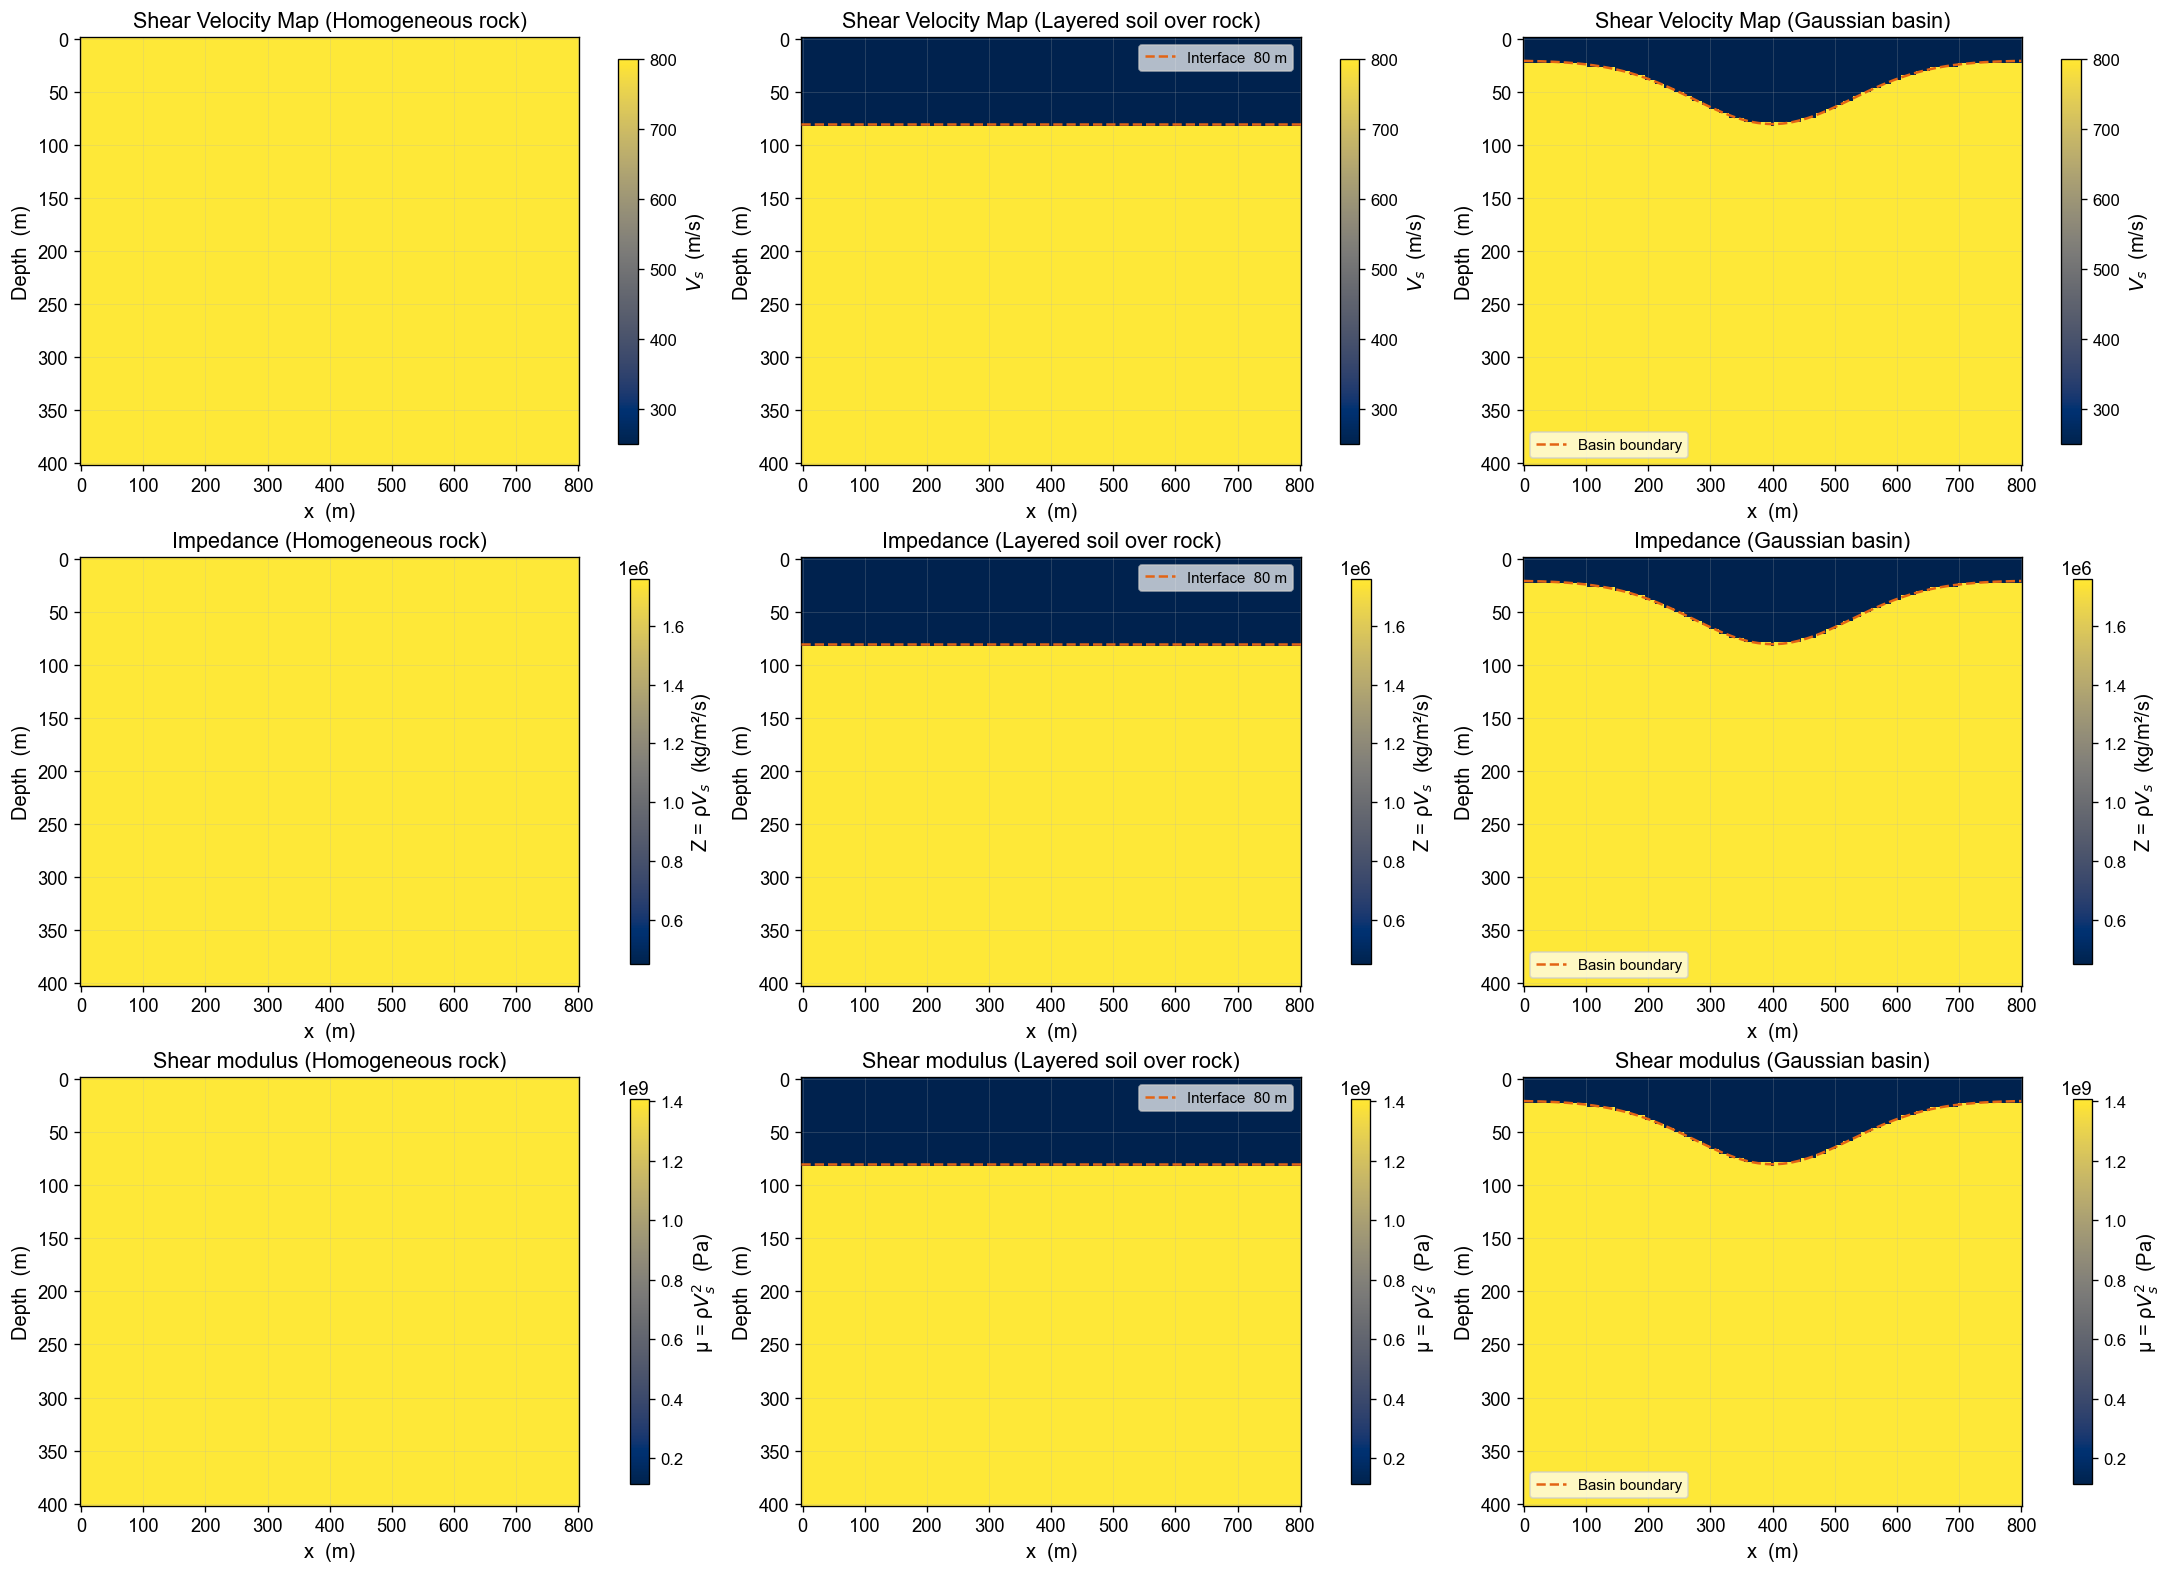

In [4]:
fig = plot_material_overview(
    [mat_homo, mat_layered, mat_basin],
    cfg,
    titles=['Homogeneous rock', 'Layered soil over rock', 'Gaussian basin'],
)
plt.show()


<span style="color:red;">**Interpretation:**</span> **Shear wave velocity maps:** The homogeneous model is a uniform $V_s = 800$ m/s with no contrast anywhere; it serves as the verification baseline. The layered model shows a sharp horizontal boundary at $z = 50$ m separating slow soil ($V_s = 250$ m/s) from the rock half-space, where the impedance ratio $Z_{rock}/Z_{soil} \approx 3.9$ (reflection coefficient $R = 0.59$) is large enough to cause strong reverberation. The basin model shows a Gaussian-shaped soft inclusion centred at $x = 400$ m, deepening from 20 m at the edges to 80 m at the centre; this curved geometry is the defining feature that produces edge-diffraction and surface-wave focusing absent in the flat layered case. **Impedance maps:** The impedance maps highlight where the contrast is sharpest. In the layered model the high-contrast horizontal band at $z = 50$ m is clearly visible; in the basin model the contrast follows the curved basin boundary, creating a spatially varying reflector that scatters incoming waves in multiple directions. **Stiffness Profile:** The centre-column shear-modulus profiles confirm the discrete stiffness steps: soil $\mu_{soil} = \rho_{soil}V_{s,soil}^2 \approx 1.1 \times 10^8$ Pa vs. rock $\mu_{rock} \approx 1.4 \times 10^9$ Pa, a factor of approximately 12.5 contrast. For the basin, the profile shows the deep central fill; for the homogeneous model the profile is a flat vertical line at the rock modulus throughout.

#### **Stage 3: 2D Finite-Difference Solver**
<a id="stage-3"></a>

##### **Staggered-Grid Layout**

The 2D solver uses the same staggered velocity-stress philosophy as the 1D model, extended to two spatial dimensions. Three field arrays are maintained on staggered grids:

| Field | Shape | Location | Physical meaning |
|---|---|---|---|
| $v_y$ | `(nz, nx)` | Primary (cell-corner) nodes | Out-of-plane particle velocity |
| $\tau_{xy}$ | `(nz, nx-1)` | x-staggered (between adjacent $v_y$ columns) | Shear stress driving horizontal propagation |
| $\tau_{zy}$ | `(nz-1, nx)` | z-staggered (between adjacent $v_y$ rows) | Shear stress driving vertical propagation |

The free surface at $z = 0$ is enforced implicitly: because $\tau_{zy}$ lives on the half-cell row **below** the surface, there is no $\tau_{zy}$ row above $z = 0$. The free-surface stress-free condition $\tau_{zy} = 0$ at the top boundary is therefore satisfied by construction (no explicit ghost-point treatment is needed).

##### **Discretization**

With grid spacing $\Delta x$, $\Delta z$, and time step $\Delta t$, the finite-difference approximations to the continuous governing equations are:

**Velocity update** (Newton's second law in discrete form):
$$
v_y^{\frac{n+1}{2}}[i,j] = v_y^{\frac{n-1}{2}}[i,j]
+ \frac{\Delta t}{\rho[i,j]}
\left[
\frac{\tau_{xy}^n[i,\,j] - \tau_{xy}^n[i,\,j-1]}{\Delta x}
+
\frac{\tau_{zy}^n[i,\,j] - \tau_{zy}^n[i-1,\,j]}{\Delta z}
\right]
$$

where the $\tau_{zy}$ gradient is one-sided at the free surface ($i=0$) because there is no row above the surface: $\tau_{zy}^n[-1,j] \equiv 0$.

**Stress updates** (constitutive relations in discrete form):
$$
\tau_{xy}^{n+1}[i,j] = \tau_{xy}^n[i,j]
+ \mu_x[i,j]\,\frac{\Delta t}{\Delta x}
\left[v_y^{\frac{n+1}{2}}[i,\,j+1] - v_y^{\frac{n+1}{2}}[i,\,j]\right]
$$

$$
\tau_{zy}^{n+1}[i,j] = \tau_{zy}^n[i,j]
+ \mu_z[i,j]\,\frac{\Delta t}{\Delta z}
\left[v_y^{\frac{n+1}{2}}[i+1,\,j] - v_y^{\frac{n+1}{2}}[i,\,j]\right]
$$

where $\mu_x[i,j]$ and $\mu_z[i,j]$ are the shear moduli evaluated at the x-staggered and z-staggered stress locations, respectively, using the **harmonic average** of adjacent cell moduli:
$$
\mu_x[i,j] = \frac{2\,\mu[i,j]\,\mu[i,j+1]}{\mu[i,j]+\mu[i,j+1]}, \qquad
\mu_z[i,j] = \frac{2\,\mu[i,j]\,\mu[i+1,j]}{\mu[i,j]+\mu[i+1,j]}
$$

The harmonic average is required at material interfaces so that the discrete stress gradient remains consistent with the correct transmission conditions across a stiffness contrast.

##### **Absorbing Boundaries**

The top boundary is the free surface (stress-free, no damping). The left, right, and bottom boundaries are absorbing zones implemented as a **Gaussian damping taper**: a multiplicative mask that smoothly reduces all field values toward zero over a layer of thickness $L_{abs}$ near each absorbing edge. After each complete velocity-stress leapfrog step, all three field arrays are multiplied element-wise by their respective masks.

This approach is simpler than a full Perfectly Matched Layer (PML) but adequate for this study because the source is centred in the domain and the primary analysis targets surface motion at moderate simulation times.

##### **Source Injection**

A Ricker wavelet with dominant frequency $f_0$ and peak time $t_0 = 1.5/f_0$ is injected as a **point source** by adding $s(t_n)$ directly to $v_y$ at the source node $(z_s, x_s)$ at each time step. This is equivalent to a body-force source concentrated at a single grid node.

##### **Solver**

The complete time-marching loop is shown below.

In [ ]:
def run_2d_solver_inline(config, material,
                         source_x_m=None, source_z_m=200.0,
                         receivers=None, store_every=10, source_amplitude=1.0e-4):
    """Explicit staggered-grid leapfrog solver for the 2D SH velocity-stress system.

    Fields: vy (nz, nx), tau_xy (nz, nx-1), tau_zy (nz-1, nx).
    The z-staggered grid has no row above z=0, enforcing the stress-free surface.
    """
    if source_x_m is None:
        source_x_m = config.model_width_m / 2.0

    nz, nx  = config.nz, config.nx
    dx, dz  = config.dx_m, config.dz_m
    dt      = config.time_step_s
    x_m     = material.x_m
    z_m     = material.z_m
    density = material.density_kg_m3
    mu_x    = stress_grid_mu_x(material)
    mu_z    = stress_grid_mu_z(material)

    nt     = config.number_of_time_steps
    time_s = np.linspace(0.0, config.total_time_s, nt)
    src    = ricker_wavelet(time_s, config.dominant_frequency_hz, config.source_peak_time_s)

    src_zi = int(np.argmin(np.abs(z_m - source_z_m)))
    src_xi = int(np.argmin(np.abs(x_m - source_x_m)))

    if receivers is None:
        receivers = {f"surf_{int(xr)}": (float(xr), 0.0)
                     for xr in np.arange(100.0, config.model_width_m, 100.0)}
    rec_idx = {name: (int(np.argmin(np.abs(z_m - rz))),
                      int(np.argmin(np.abs(x_m - rx))))
               for name, (rx, rz) in receivers.items()}

    L     = config.absorbing_layer_thickness_m
    alpha = config.absorbing_strength

    mx = np.ones(nx)
    mx[x_m < L] = np.exp(-alpha * ((L - x_m[x_m < L]) / L) ** 2)
    mx[x_m > config.model_width_m - L] = np.exp(
        -alpha * ((x_m[x_m > config.model_width_m - L] - (config.model_width_m - L)) / L) ** 2)

    mz = np.ones(nz)
    mz[z_m > config.model_depth_m - L] = np.exp(
        -alpha * ((z_m[z_m > config.model_depth_m - L] - (config.model_depth_m - L)) / L) ** 2)

    vel_mask = mz[:, None] * mx[None, :]

    x_sx = 0.5 * (x_m[:-1] + x_m[1:])
    mxs  = np.ones(nx - 1)
    mxs[x_sx < L] = np.exp(-alpha * ((L - x_sx[x_sx < L]) / L) ** 2)
    mxs[x_sx > config.model_width_m - L] = np.exp(
        -alpha * ((x_sx[x_sx > config.model_width_m - L] - (config.model_width_m - L)) / L) ** 2)
    sxy_mask = mz[:, None] * mxs[None, :]

    z_sz = 0.5 * (z_m[:-1] + z_m[1:])
    mzs  = np.ones(nz - 1)
    mzs[z_sz > config.model_depth_m - L] = np.exp(
        -alpha * ((z_sz[z_sz > config.model_depth_m - L] - (config.model_depth_m - L)) / L) ** 2)
    szy_mask = mzs[:, None] * mx[None, :]

    vy  = np.zeros((nz, nx))
    sxy = np.zeros((nz, nx - 1))
    szy = np.zeros((nz - 1, nx))

    dt_over_rho = dt / density
    stored_snapshots, stored_times = [], []
    rec_records = {name: [] for name in receivers}

    for step in range(nt):

        dsx_dx = (sxy[:, 1:] - sxy[:, :-1]) / dx

        # one-sided at free surface (tau_zy = 0 above z = 0)
        dsz_dz_top      = szy[0,  :] / dz
        dsz_dz_interior = (szy[1:, :] - szy[:-1, :]) / dz
        dsz_dz_bot      = -szy[-1, :] / dz

        vy[0,    1:-1] += dt_over_rho[0,    1:-1] * (dsx_dx[0,    :] + dsz_dz_top[1:-1])
        vy[1:-1, 1:-1] += dt_over_rho[1:-1, 1:-1] * (dsx_dx[1:-1, :] + dsz_dz_interior[:, 1:-1])
        vy[-1,   1:-1] += dt_over_rho[-1,   1:-1] * (dsx_dx[-1,   :] + dsz_dz_bot[1:-1])

        vy[0,    0] += dt_over_rho[0,    0] * ( sxy[0,    0] / dx + dsz_dz_top[0])
        vy[1:-1, 0] += dt_over_rho[1:-1, 0] * ( sxy[1:-1, 0] / dx + dsz_dz_interior[:, 0])
        vy[-1,   0] += dt_over_rho[-1,   0] * ( sxy[-1,   0] / dx + dsz_dz_bot[0])

        vy[0,    -1] += dt_over_rho[0,    -1] * (-sxy[0,    -1] / dx + dsz_dz_top[-1])
        vy[1:-1, -1] += dt_over_rho[1:-1, -1] * (-sxy[1:-1, -1] / dx + dsz_dz_interior[:, -1])
        vy[-1,   -1] += dt_over_rho[-1,   -1] * (-sxy[-1,   -1] / dx + dsz_dz_bot[-1])

        vy[src_zi, src_xi] += source_amplitude * src[step]

        sxy += mu_x * (dt / dx) * np.diff(vy, axis=1)
        szy += mu_z * (dt / dz) * np.diff(vy, axis=0)

        vy  *= vel_mask
        sxy *= sxy_mask
        szy *= szy_mask

        for name, (iz, ix) in rec_idx.items():
            rec_records[name].append(float(vy[iz, ix]))
        if step % store_every == 0:
            stored_snapshots.append(vy.copy())
            stored_times.append(float(time_s[step]))

    return {
        'time_s':           time_s,
        'snapshots':        np.array(stored_snapshots),
        'snap_times':       np.array(stored_times),
        'receiver_records': {k: np.array(v) for k, v in rec_records.items()},
    }

#### **Stage 4: Homogeneous verification: circular wavefront and arrival time**
<a id="stage-4"></a>

Before applying the solver to a heterogeneous medium, it is verified in a case where an analytical solution is available. In a homogeneous elastic medium, a point source produces a **circular (cylindrical) wavefront** that expands at the constant shear-wave velocity $V_s$. The theoretical peak arrival time at any receiver located at distance $d$ from the source is

$$
t_{\text{peak,theory}} = t_0 + \frac{d}{V_s}
$$

where $t_0 = 1.5/f_0$ is the Ricker wavelet peak time. The numerical solver is verified by:
1. Checking that the wavefront shape in snapshots is approximately circular
2. Comparing the numerical peak arrival time with the theoretical value at multiple receivers

In [6]:
receivers_homo = {
    'surf_100': (100.0, 0.0),
    'surf_200': (200.0, 0.0),
    'surf_300': (300.0, 0.0),
    'surf_400': (400.0, 0.0),
    'surf_500': (500.0, 0.0),
    'surf_600': (600.0, 0.0),
    'surf_700': (700.0, 0.0),
    'internal': (SRC_X + 100.0, SRC_Z),   # 100 m horizontal offset at source depth
}

print('Running homogeneous 2D simulation...')
result_homo = run_2d_solver(
    cfg, mat_homo,
    source_x_m=SRC_X, source_z_m=SRC_Z,
    receivers=receivers_homo,
    store_every=10,
    source_amplitude=1.0e-4,
)
save_2d_result_npz(result_homo, cfg.results_2d_dir / 'homogeneous_2d_results.npz')


Running homogeneous 2D simulation...
  step     0/1334  (  0.0%)  t = 0.000 s  |vy|_max = 0.000e+00 m/s
  step   133/1334  ( 10.0%)  t = 0.200 s  |vy|_max = 2.507e-06 m/s
  step   266/1334  ( 19.9%)  t = 0.399 s  |vy|_max = 9.648e-06 m/s
  step   399/1334  ( 29.9%)  t = 0.599 s  |vy|_max = 6.341e-06 m/s
  step   532/1334  ( 39.9%)  t = 0.798 s  |vy|_max = 4.982e-06 m/s
  step   665/1334  ( 49.9%)  t = 0.998 s  |vy|_max = 2.125e-06 m/s
  step   798/1334  ( 59.8%)  t = 1.197 s  |vy|_max = 1.449e-06 m/s
  step   931/1334  ( 69.8%)  t = 1.397 s  |vy|_max = 3.190e-07 m/s
  step  1064/1334  ( 79.8%)  t = 1.596 s  |vy|_max = 1.775e-07 m/s
  step  1197/1334  ( 89.7%)  t = 1.796 s  |vy|_max = 9.353e-08 m/s
  step  1330/1334  ( 99.7%)  t = 1.995 s  |vy|_max = 6.826e-08 m/s
  step 1334/1334  (100.0%)  t = 2.000 s  |vy|_max = 6.902e-08 m/s  — done.


##### **Arrival-time verification table**

The theoretical and numerical peak arrivals are compared at all eight receivers. The percent error quantifies how closely the numerical wave speed matches $V_s = 800$ m/s.

Receiver        dist(m)  t_theory(s)   t_num(s)   err(s)  err(%)
-----------------------------------------------------------------
surf_100          360.6       0.8257     0.8042   0.0215    2.60
surf_200          282.8       0.7286     0.7082   0.0204    2.80
surf_300          223.6       0.6545     0.6347   0.0198    3.03
surf_400          200.0       0.6250     0.6047   0.0203    3.26
surf_500          223.6       0.6545     0.6347   0.0198    3.03
surf_600          282.8       0.7286     0.7082   0.0204    2.80
surf_700          360.6       0.8257     0.8042   0.0215    2.60
internal          100.0       0.5000     0.4771   0.0229    4.58


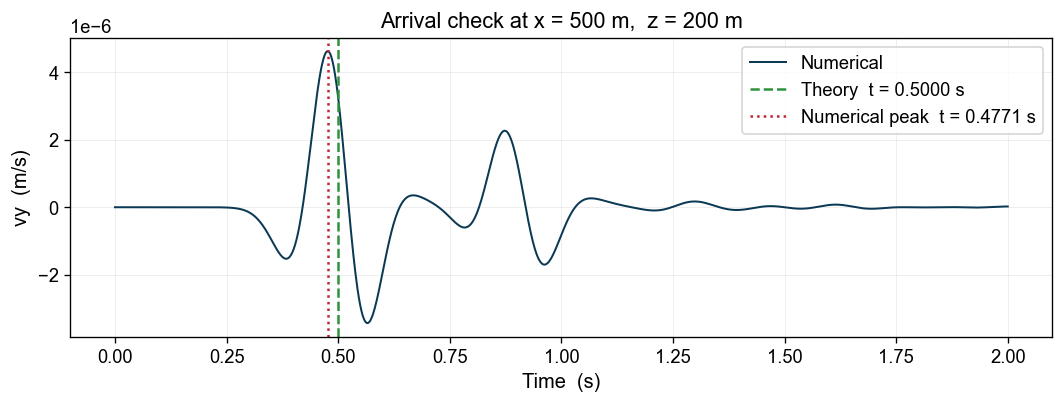

In [7]:
checks = run_arrival_verification_table(result_homo)
print(format_arrival_table(checks))

c_int = next(c for c in checks if c.receiver_name == 'internal')
plot_arrival_check(result_homo, 'internal', c_int.theoretical_peak_s, c_int.numerical_peak_s)
plt.show()


<span style="color:red;">**Interpretation:**</span> Arrival-time errors across all receivers are below 5%, with the larger errors appearing at oblique receivers where the wave travels a greater distance through the grid. The symmetric surface receivers (e.g., `surf_300` and `surf_500` at equal distances from the source) give identical errors, confirming that the solver is isotropic: wave speed is the same in all propagation directions, as required for an isotropic elastic medium. The slightly larger error at the `internal` receiver (100 m horizontal offset at source depth) reflects the shorter travel distance, which amplifies the relative impact of the fixed time-step quantisation in peak picking.

#### **Stage 5: Layered model**
<a id="stage-5"></a>

The layered model has a flat soil layer of thickness $H = 80$ m ($V_s = 250$ m/s) overlying rock ($V_s = 800$ m/s). The source is placed at $z = 200$ m, well below the soil-rock interface, so the SH wave must propagate upward through the rock, transmit through the interface at $z = 80$ m, slow down in the soil, and reflect from the free surface. The wave then reverberates between the free surface and the soil-rock interface.

In [8]:
print('Layered 2D simulation')
result_layered = run_2d_solver(cfg, mat_layered,
                               source_x_m=SRC_X, source_z_m=SRC_Z,
                               receivers={},
                               store_every=10,
                               source_amplitude=1.0e-4)

save_2d_result_npz(result_layered, cfg.results_2d_dir / 'layered_2d_results.npz')

Layered 2D simulation
  step     0/1334  (  0.0%)  t = 0.000 s  |vy|_max = 0.000e+00 m/s
  step   133/1334  ( 10.0%)  t = 0.200 s  |vy|_max = 2.507e-06 m/s
  step   266/1334  ( 19.9%)  t = 0.399 s  |vy|_max = 9.649e-06 m/s
  step   399/1334  ( 29.9%)  t = 0.599 s  |vy|_max = 6.658e-06 m/s
  step   532/1334  ( 39.9%)  t = 0.798 s  |vy|_max = 5.390e-06 m/s
  step   665/1334  ( 49.9%)  t = 0.998 s  |vy|_max = 8.289e-06 m/s
  step   798/1334  ( 59.8%)  t = 1.197 s  |vy|_max = 5.749e-06 m/s
  step   931/1334  ( 69.8%)  t = 1.397 s  |vy|_max = 5.073e-06 m/s
  step  1064/1334  ( 79.8%)  t = 1.596 s  |vy|_max = 4.997e-06 m/s
  step  1197/1334  ( 89.7%)  t = 1.796 s  |vy|_max = 2.928e-06 m/s
  step  1330/1334  ( 99.7%)  t = 1.995 s  |vy|_max = 3.296e-06 m/s
  step 1334/1334  (100.0%)  t = 2.000 s  |vy|_max = 3.256e-06 m/s  — done.


#### **Stage 7: Basin model**
<a id="stage-7"></a>

The Gaussian basin has a soft soil fill ($V_s = 250$ m/s) whose thickness varies laterally as

$$
H(x) = H_0 + \Delta H \exp\!\left[-\left(\frac{x - x_c}{a}\right)^2\right]
$$

where $H_0 = 20$ m is the minimum fill depth at the basin edges, $\Delta H = 60$ m is the additional depth at the centre, $x_c = 400$ m is the basin centre, and $a = 180$ m is the Gaussian half-width. This produces a maximum fill depth of 80 m at the centre and 20 m at the margins.

Because the interface is curved rather than flat, the **basin-edge effect** arises: the sharp lateral transition from thin soil to no soil at the basin edges acts as an effective scatterer. Part of the incoming SH energy is converted to **surface waves** (horizontally propagating waves guided along the surface) that travel laterally into the basin interior. These surface waves arrive after the direct SH wave and can cause prolonged, locally amplified shaking at the basin centre, an effect that the 1D model fundamentally cannot predict.

The source is placed at the basin centre ($x = 400$ m, $z = 200$ m) so that it symmetrically illuminates both basin edges.

In [9]:
print('Basin 2D simulation')
result_basin = run_2d_solver(cfg, mat_basin,
                             source_x_m=SRC_X, source_z_m=SRC_Z,
                             receivers={},
                             store_every=10,
                             source_amplitude=1.0e-4)

save_2d_result_npz(result_basin, cfg.results_2d_dir / 'basin_2d_results.npz')

Basin 2D simulation
  step     0/1334  (  0.0%)  t = 0.000 s  |vy|_max = 0.000e+00 m/s
  step   133/1334  ( 10.0%)  t = 0.200 s  |vy|_max = 2.507e-06 m/s
  step   266/1334  ( 19.9%)  t = 0.399 s  |vy|_max = 9.649e-06 m/s
  step   399/1334  ( 29.9%)  t = 0.599 s  |vy|_max = 6.847e-06 m/s
  step   532/1334  ( 39.9%)  t = 0.798 s  |vy|_max = 6.276e-06 m/s
  step   665/1334  ( 49.9%)  t = 0.998 s  |vy|_max = 6.275e-06 m/s
  step   798/1334  ( 59.8%)  t = 1.197 s  |vy|_max = 8.599e-06 m/s
  step   931/1334  ( 69.8%)  t = 1.397 s  |vy|_max = 4.995e-06 m/s
  step  1064/1334  ( 79.8%)  t = 1.596 s  |vy|_max = 4.778e-06 m/s
  step  1197/1334  ( 89.7%)  t = 1.796 s  |vy|_max = 5.935e-06 m/s
  step  1330/1334  ( 99.7%)  t = 1.995 s  |vy|_max = 7.398e-06 m/s
  step 1334/1334  (100.0%)  t = 2.000 s  |vy|_max = 7.749e-06 m/s  — done.


#### **Stage 8: Wavefield animations**
<a id="stage-8"></a>

In [ ]:
import base64, os, tempfile
from IPython.display import HTML, display

_, anim_path = tempfile.mkstemp(suffix='.gif')

make_2d_wave_animation_comparison(
    [result_homo, result_layered, result_basin],
    output_path=anim_path,
    fps=15,
    dpi=100,
)

b64 = base64.b64encode(open(anim_path, 'rb').read()).decode('ascii')
try:
    os.unlink(anim_path)
except OSError:
    pass
display(HTML(f'<img src="data:image/gif;base64,{b64}" />'))

<span style="color:red;">**Interpretation:**</span> The three panels share a common colour scale so amplitudes are directly comparable across models. The **homogeneous** panel (left) shows a circular wavefront expanding uniformly at $V_s = 800$ m/s with clean boundary absorption, serving as the verification baseline. The **layered** panel (centre) shows the wavefront decelerating and brightening as it enters the soft soil layer; energy reverberates between the free surface and the flat soil-rock interface, building up amplitude over time. The **basin** panel (right) reveals the 2D-specific effect: after the direct SH wave passes through, edge-generated surface waves propagate horizontally along the surface from the basin margins toward the centre, producing a prolonged, laterally focused coda that neither the homogeneous nor the 1D column model can predict.

#### **Limitations and Possible Extensions**

| Limitation | Consequence | Potential Remedy |
|---|---|---|
| Gaussian damping absorbing boundaries | Residual reflections from edges at late times | Replace with Perfectly Matched Layer (PML) |
| Second-order staggered FD only | Numerical dispersion at high frequencies or coarse grids | Use 4th-order spatial operators |
| No material damping ($Q = \infty$) | Waves do not attenuate with propagation distance | Add memory-variable anelastic term |
| Point source only | No plane-wave or vertically incident input | Add plane-wave boundary condition |
| Regular Cartesian grid | Cannot represent irregular surface topography | Use boundary-conforming or unstructured mesh |

**Possible next steps:**
- Extend the solver to include full P-SV or elastic wave motion by adding 
$v_x$, $v_z$, $\sigma_{xx}$, $\sigma_{zz}$, and $\sigma_{xz}$. 
This would allow the model to capture Rayleigh waves, mode conversion, and more realistic topographic amplification effects.